Nome: Laura Vieira Malachias

RA: 299117

Curso: Mestrado em Tecnologia



# Ex03 - Transformações de Intensidade (operações radiométricas)

Esta atividade tem 2 objetivos principais: 
  - Entender o que são transformações radiométricas e como podem ser implementadas
  - Explorar duas aplicações para as transformações radiométricas: normalização e segmentação. 

In [28]:
# Importando as bibliotecas que serão utilizadas
import os

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import requests
from PIL import Image

In [29]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

## Parte 1 - Manipulando imagens

O código abaixo baixa e lê a imagem *flower.pgm* utilizando a biblioteca PIL/pillow, apresenta a imagem na tela e a transforma num array numpy.

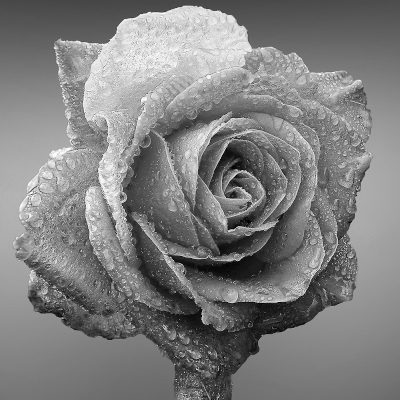

[[ 72  72  72 ...  78  77  77]
 [ 73  72  73 ...  78  78  78]
 [ 73  73  74 ...  78  78  79]
 ...
 [118 117 116 ... 107 107 106]
 [116 115 115 ... 106 106 106]
 [116 116 115 ... 106 106 106]]


In [30]:
url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/flower.pgm"
img_file = download_image(url)
img = Image.open(img_file)
display(img)

# Convertendo para um array do numpy
f=np.asarray(img)
print(f)

É bastante útil poder transformar Images em PIL em arrays numpy, e vice-versa. Isso permitirá que realizemos operações matriciais nas imagens e posteriormente possamos visualizar (e salvar em arquivos) as imagens processadas. 

### Exercício 1.1 

**a)** Classifique a imagem como monocromática (binária, grayscale) ou multibanda (tentando identificar o padrão multibanda adotado). Descubra: qual a profundidade da imagem? Qual o maior e o menor valor de intensidade de pixel da imagem (da imagem, não o teórico da profundidade)? Utilize para isso a biblioteca NumPy.

In [31]:
print(f.shape)    
print(f.dtype)    
print(f.min())    
print(f.max())    

(400, 400)
uint8
0
253


### Resposta
Como a imagem não fornece canal, apenas a dimensão (400 px de altura, 400 px de largura), compreende-se que ela é monocromática (grayscale). Além disso, o tipo da imagem é mostrado como unit8, ou seja, possui 8bits de profundidade por pixel. Os valores mínimo e máximo da imagem é 0 e 253, respectivamente, o que também demostra que a imagem não tem branco puro (255).

**b)** Leia a imagem *flower.pgm* utilizando a biblioteca matplotlib.image e mostre-a na tela. Exercite também o uso da barra de cores (colorbar).

Referência: [Tutorial Image Matplotlib](https://matplotlib.org/3.5.0/tutorials/introductory/images.html) 

<details>
<summary>Dicas</summary>

- [matplotlib.pyplot.colobar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.colorbar.html)

</details>

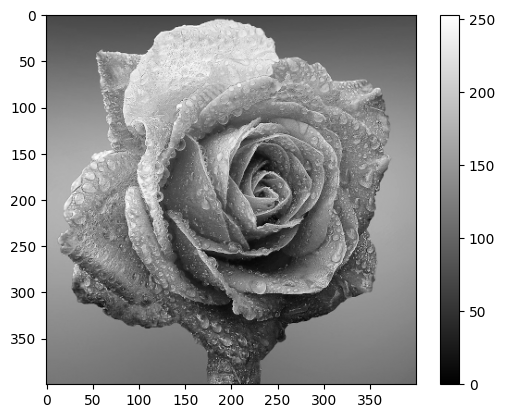

In [32]:
f = mpimg.imread(img_file)

plt.imshow(f, cmap='gray')
plt.colorbar()
plt.show()

**c)** Usando atributos do tipo [`Image`](https://pillow.readthedocs.io/en/stable/reference/Image.html#image-attributes) da biblioteca `PIL`, tente responder as mesmas perguntas do item **a)**.

In [33]:
img = Image.open(img_file)

print(img.mode)   
print(img.size)   

L
(400, 400)


### Resposta: 
O Image.mode retorna a profundidade de bits por imagem. Desse modo, usando a imagem do exercício e tendo retornado "L" entende-se (usando a documentação como base), que a imagem tem pixels de 8 bits, escala de cinza, portanto, o intervalo é de valores é de 0 a 255.
Interessante perceber que em numpy, as dimensões são dadas por (altura, largura), enquanto que em PIL Image.size retorna (largura, altura).

---

### Exercício 1.2

Imagine que a imagem está um pouco clara demais e decido escurecê-la um pouco. Minha primeira ideia seria subtrair um valor de cada pixel, uma vez que valores menores correspondem a cores mais escuras. 

[[235 235 235 ... 241 240 240]
 [236 235 236 ... 241 241 241]
 [236 236 237 ... 241 241 242]
 ...
 [ 25  24  23 ...  14  14  13]
 [ 23  22  22 ...  13  13  13]
 [ 23  23  22 ...  13  13  13]]


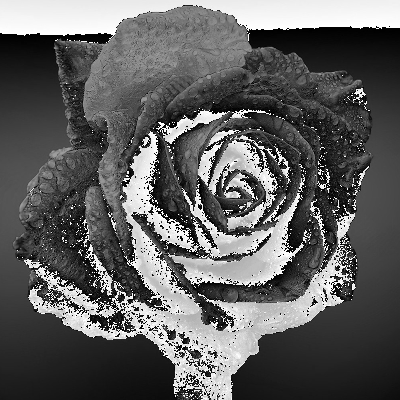

In [34]:
# Vou escurecer a imagem, subtraindo um valor dos pixels do array f.
g=f-93 
print(g)
# Agora vou transformar o array numa imagem PIL
g_img=Image.fromarray(g)
# E visualizar o resultado usando a função do PIL display
display(g_img)

**a)** Porque a imagem ficou mais clara ao invés de mais escura? Explique porque ao subtrair um determinado valor de intensidade da imagem original algumas regiões da imagem ficaram saturadas em branco.

### Resposta:
Como visto nos exercícios anteriores, o dtype da imagem é uint8, os valores vão de 0 a 255. Então pixels que tinham valores menores que 93 (valor a ser subtraído de f) se tornam negativos, contudo, uint8 não suporta valores negativos. Então, acontece um underflow: o valor "dá a volta" pelo limite inferior e retorna ao topo do intervalo (ex: 72 - 93 = -21  ->  256 - 21 = 235), resultando em tons claros.
Dessa forma, pixels menores que 93 ficam brancos e pixels maiores que 93 ficam escuros como se pretendia originalmente.

---
A principal mensagem é que podemos realizar operações quaisquer com os valores de pixel mas, no fim do dia, caso queiramos visualizar essas imagens, temos que pensar como esses valores serão mapeados para uma codificação que faça sentido no seu sistema computacional de apresentação.


**b)** Tente refazer esta mesma operação de "escurecimento" da imagem através de subtração, sem que esse efeito de saturação aconteça. Comente os métodos utilizados.

<details>
<summary>Dicas</summary>

- [numpy.clip](https://numpy.org/doc/stable/reference/generated/numpy.clip.html)

</details>

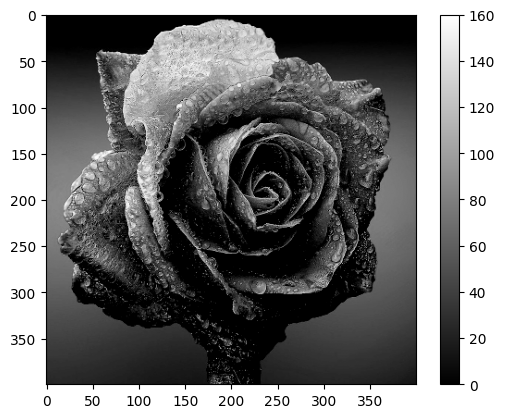

In [35]:
g = f.astype(int) - 93
g = np.clip(g, 0, 255).astype(np.uint8)

plt.imshow(g, cmap='gray')
plt.colorbar()
plt.show()

### Método usado
O numpy tem uma função denominada de clip, na qual dado um intervalo, os valores fora do intervalo são limitados aos seus limites. Isto é, se definirmos que o limite inferior é 0 e o superior é 255, valores abaixo de 0 serão considerados 0, e valores superiores a 255, serão considerados como 255. <br>
Sendo assim, primeiro f é convertido de de uint8 para int, para suportar valores negativos antes de subtrair. Depois, np.clip limita todos os valores ao intervalo 0–255 e posterioremente, reconverte para uint8, formato da imagem. 

---

## Parte 2 - Transformação de Intensidade

Tranformações de intensidade ou transformações rediométricas alteram o valor do pixel aplicando-se uma função ou tabela de mapeamento. Para entender como isso é implementado na prática, estudem atentamente o tutorial sobre ["Transformações de intensidade"](https://github.com/lrittner/Computacao-Visual/blob/master/tutoriais/tutorial_ti_2.ipynb).

Vamos exercitar a aplicação de um mapeamento f = T[f] a partir de uma função de transformação T. No nosso caso, a função T será o negativo da imagem.

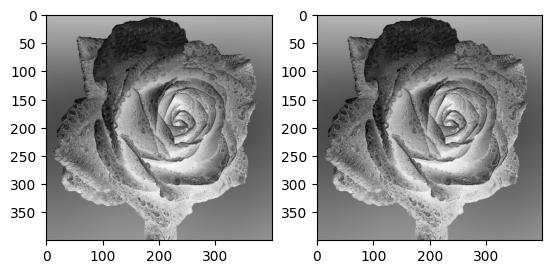

In [36]:
T = np.arange(256).astype('uint8')        # função identidade
T1 = 255 - T                              # criando a função negação a partir da identidade
#print(T1)
T2 = np.arange(255,-1,-1).astype('uint8') # criando diretamente a função negação
#print(T2)

plt.subplot(1,2,1)
f1 = T1[f]
plt.imshow(f1,cmap='gray')
plt.subplot(1,2,2)
f2 = T2[f]
plt.imshow(f2,cmap='gray')


### Exercício 2.1

Utilize transformações radiométricas para transformar a imagem e identificar o número da placa do carro apresentado na imagem abaixo. Explique seu raciocínio para chegar na solução.

float32


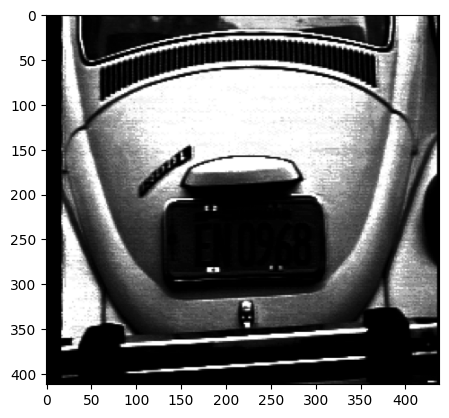

In [37]:
fusca_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/fusca.png"
f = mpimg.imread(download_image(fusca_url))  
plt.imshow(f,cmap='gray')
print(f.dtype)

[[0.         0.         0.         ... 0.16862746 0.01176471 0.        ]
 [0.         0.         0.         ... 0.1882353  0.01568628 0.        ]
 [0.         0.         0.         ... 0.22745098 0.01568628 0.        ]
 ...
 [0.         0.         0.         ... 0.17254902 0.01176471 0.        ]
 [0.         0.         0.         ... 0.04705882 0.00392157 0.        ]
 [0.         0.         0.         ... 0.00784314 0.         0.        ]]


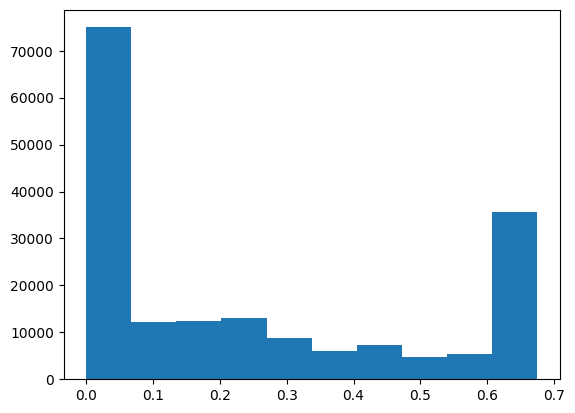

In [38]:
print(f)
plt.hist(f.ravel(), bins=10)
plt.show()

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

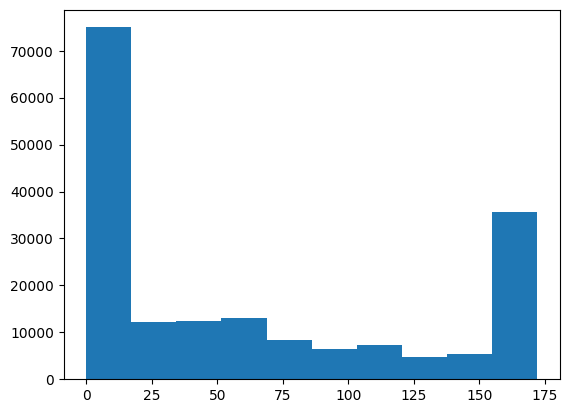

In [39]:
f_uint8 = (f * 255).astype(np.uint8)
T = np.arange(256).astype('uint8')

print(T)

plt.hist(f_uint8.ravel(), bins=10)
plt.show()

In [40]:
T_placa = np.clip((T / 5) * 255, 0, 255).astype('uint8')

print(T_placa)

[  0  51 102 153 204 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 25

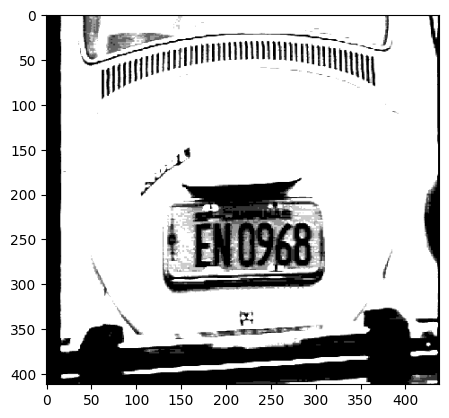

In [41]:
f_transform = T_placa[f_uint8]
plt.imshow(f_transform, cmap='gray')
plt.show()

### Método usado
Considerando que a imagem estava em float32, fiz `print(f)` para visualizar a matriz. Posteriormente, plotei um histograma para compreender a distribuição de intensidade, que mostrou valores entre 0.0 e 0.6. Usei ravel(), pois ele transforma a matriz 2D da imagem em um array 1D, então ele "achata" todos os pixels em uma sequência só para o histograma contar as frequências.

Como a imagem estava em float, multipliquei por 255 e converti para uint8. Depois, criei a tabela identidade `T = np.arange(256)`, com cada valor mapeando a si mesmo, e replotei o histograma — a distribuição permanece a mesma, apenas a escala muda.

Em `T_placa = np.clip((T / 5) * 255, 0, 255).astype('uint8')`, dividi cada valor por 5 e multipliquei por 255, esticando o intervalo 0–5 para 0–255. O `clip` garante que valores acima de 5 sejam saturados em 255. O valor 5 foi definido iterativamente, isto é, testei valores maiores como 25 e fui reduzindo até obter a melhor visualização da placa.

Em `f_transform = T_placa[f_uint8]`, cada pixel de `f_uint8` é usado como índice em `T_placa`, conforme o método apresentado no enunciado. A imagem inteira é transformada de uma vez, amplificando o contraste na região escura onde a placa está.

---

### Exercício 2.2

Uma das possíveis aplicações das transformações radiométricas é a segmentação de imagens, onde destacamos um objeto de interesse dos demais objetos (ou do fundo). 

**a)** A imagem abaixo mostra duas bolachas. Escolha um valor de limiar (threshold) para separar a bolacha do fundo da imagem. Crie uma função de transformação T e aplique esta transformação para obter os objetos de interesse (bolachas) pintados de branco e o fundo em preto. Comente os métodos utilizados.

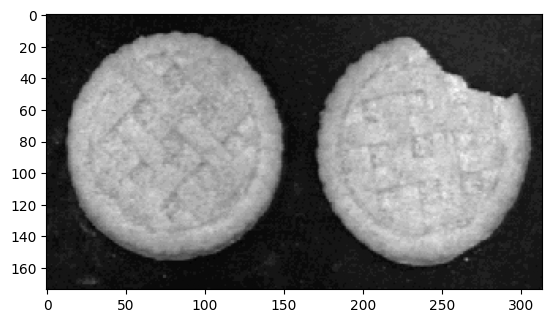

In [42]:
cookies_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/cookies.pgm"
plt.subplot(111)  
f = mpimg.imread(download_image(cookies_url))  
plt.imshow(f,cmap='gray')

[[24 32 32 ... 49 41 41]
 [32 32 24 ... 49 49 41]
 [32 32 32 ... 49 49 41]
 ...
 [32 32 32 ... 32 32 32]
 [32 32 32 ... 32 32 32]
 [32 24 32 ... 32 24 41]]
uint8


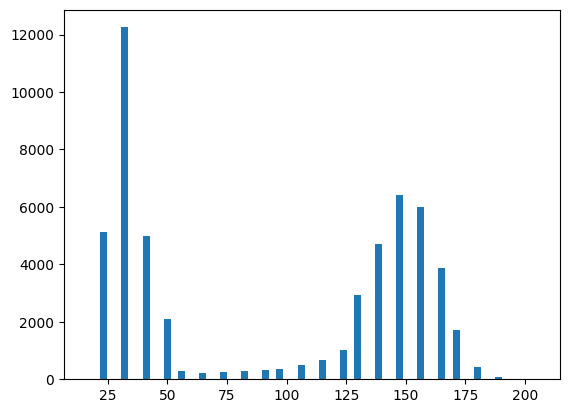

In [43]:
print(f)
print(f.dtype)
plt.hist(f.ravel(), bins=64)
plt.show()

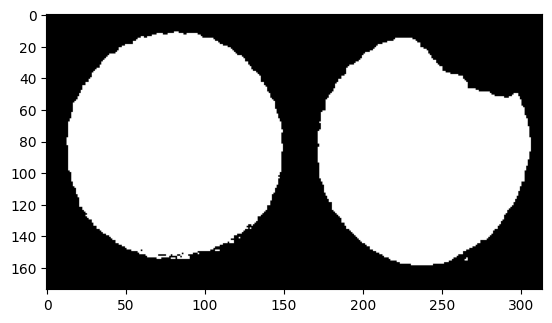

In [44]:
threshold = 80
T = np.arange(256).astype('uint8')
T_seg = np.where(T < threshold, 0, 255).astype('uint8')

f_seg = T_seg[f]
plt.imshow(f_seg, cmap='gray')
plt.show()

### Metodologia utilizada
Como a imagem já estava em uint8, não teve a necessidade de conversão. Plotei o histograma para identificar a distribuição de intensidade dos pixels, que mostrou dois grupos distintos: pixels escuros (0–50) correspondentes ao fundo e pixels claros (125–175) correspondentes às bolachas.

Com base no histograma, defini o limiar como 80, pois é o valor que cai no intervalo vazio entre os dois grupos (pixels claros e escura). o numpy possui uma função denominada de ``where``, na qual a sintaxe é ``np.where(condição, valor_se_verdadeiro, valor_se_falso)``. Considerando isso, a segmentação foi feita com `np.where(T < limiar, 255, 0)`, isto é, pixels abaixo de 80 são pretos (0) e acima são brancos (255), destacando as bolachas do fundo.
Já em `f_seg = T_seg[f]` aplica-se a transformação na imagem inteira usando indexação, resultando numa imagem binária com as bolachas em branco e o fundo em preto.

---

### Exercício 2.3 

In [45]:
orquidea_url = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/orquideafeec-calua.jpg"
download_image(orquidea_url)

'orquideafeec-calua.jpg'

Leia e apresente a imagem `orquideafeec-calua.jpg`. Execute processamentos de intensidade nas diferentes bandas da imagem (R, G, B). Comente os métodos utilizados e resultados obtidos. É possível segmentar a flor da orquídea usando uma única banda de cor?

Dica: exemplos disponíveis em [Applying point transforms e Processing individual bands](https://pillow.readthedocs.io/en/stable/handbook/tutorial.html#image-enhancement).

In [46]:
orq_url = orquidea_url
f = mpimg.imread(download_image(orq_url))
print(f.dtype, f.shape)

uint8 (1280, 960, 3)


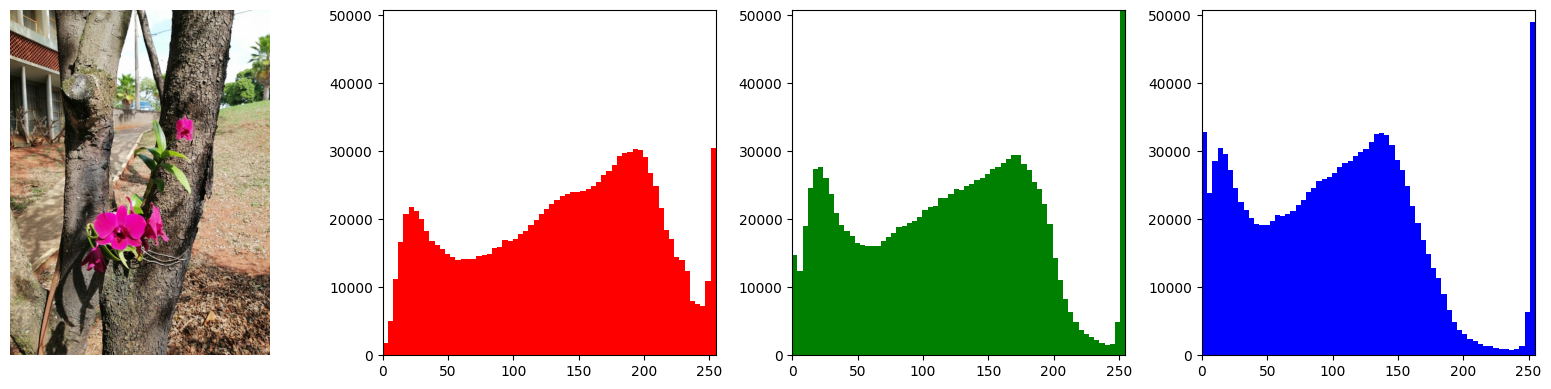

In [47]:
#def derivado do exercício 2
def plota_hist(h,cor,nbins,bin_edges):

    w=255./nbins
    bin_centers = bin_edges[1:]-(w/2)
    plt.bar(bin_centers, h, width=w, color=cor)

nbins = 64
cores = ['red', 'green', 'blue']

fig, axs = plt.subplots(1, 4, figsize=(16, 4))

axs[0].imshow(f)
axs[0].axis('off')

y_max = max(
    np.histogram(f[:, :, b], bins=nbins, range=(0, 255))[0].max()
    for b in range(3)
)

for banda in range(3):
    canal = f[:, :, banda]
    h, bin_edges = np.histogram(canal, bins=nbins, range=(0, 255))
    plt.sca(axs[banda + 1])
    plota_hist(h, cores[banda], nbins, bin_edges)
    axs[banda + 1].set_xlim(0, 255)
    axs[banda + 1].set_ylim(0, y_max)

plt.tight_layout()
plt.show()

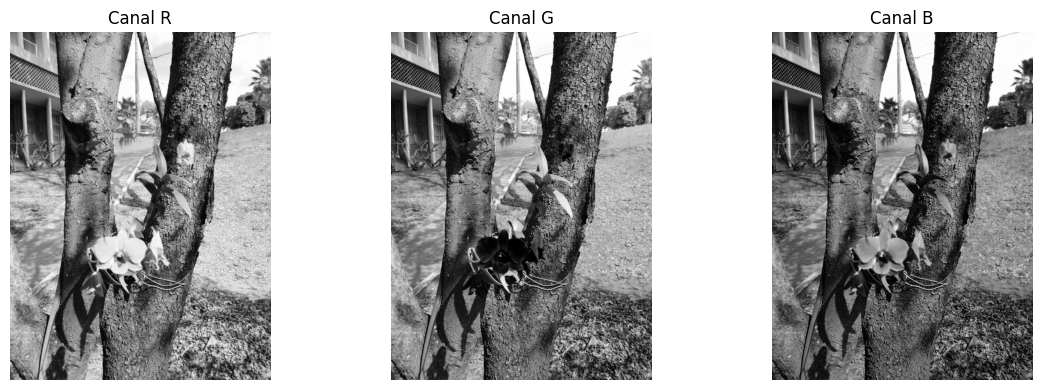

In [48]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
titulos = ['Canal R', 'Canal G', 'Canal B']

for i in range(3):
    axs[i].imshow(f[:, :, i], cmap='gray')
    axs[i].set_title(titulos[i])
    axs[i].axis('off')

plt.tight_layout()
plt.show()

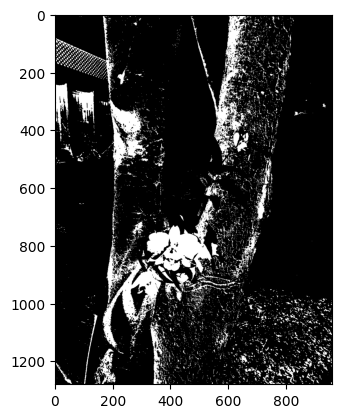

In [49]:
threshold = 30
T = np.arange(256).astype('uint8')
T_seg = np.where(T < threshold, 255, 0).astype('uint8')
f_seg = T_seg[f[:, :, 1]]

plt.imshow(f_seg, cmap='gray')
plt.show()

### Metodologia utilizada
A imagem foi carregada e os histogramas dos três canais (R, G, B) foram plotados com o mesmo limite no eixo Y para comparação. Para confirmar visualmente, cada canal foi plotado separadamente (em grayscale), no canal verde a flor aparece escura, enquanto nos canais R e B aparece clara.
Se abalisarmos o histograma do canal verde, observa-se um pico em 10 até aproximadamente 30 correspondente aos pixels da flor, que possui baixa intensidade de verde por sua composição magenta (isto é, mais vermelho e azul, mas pouco verde). Sendo assim, esse canal é o que melhor separa a flor do fundo.

Com base nisso, aplicou-se um limiar de 30 no canal verde: `T_seg = np.where(T < 30, 255, 0)`, mapeando pixels abaixo de 30 para branco para a flor e acima para preto para o fundo. A transformação foi aplicada apenas no canal verde via `T_seg[f[:, :, 1]]`, resultando numa imagem binária que segmenta a flor do restante da cena.

Então, sim, é possível fazer a segmentação utilizando apenas uma cor, mas a segmentação não é perfeita.

---

## Parte 3 - Contando moedas em uma imagem (opicional para EA979)

In [50]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

Observe atentamente e tente entender os códigos abaixo, que aplicam diversas funções e conceitos para obter o valor total de um conjunto de moedas (de 5, 10 ou 25 centavos) presentes em uma imagem. De maneira geral, foram utilizadas funções de limiarização, obtenção de componentes conexos e morfologia matemática.

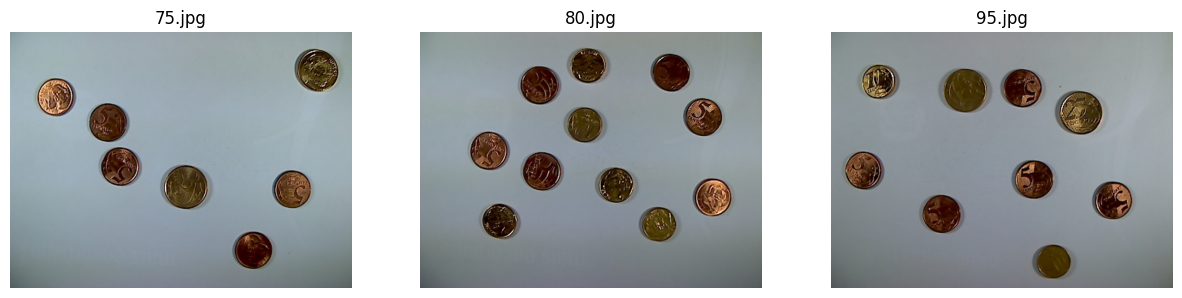

In [51]:
fig, axs = plt.subplots(1,3,figsize=(15, 6))

for i, file in enumerate(filenames):
  plt.subplot(1,3,1+i)
  plt.axis('off')
  plt.title(file)
  img = mpimg.imread(file)
  plt.imshow(img)

In [52]:
import cv2

def seg_and_postprocessing(img, k_cl, k_op):
    binr = cv2.threshold(255 - img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)[1]

    kernel_cl = np.ones((k_cl, k_cl), np.uint8) 
    kernel_op = np.ones((k_op, k_op), np.uint8) 
    
    close = cv2.morphologyEx(binr, cv2.MORPH_CLOSE, kernel_cl, iterations=1) 
    open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

    plt.figure(figsize=(12,6))
    plt.subplot(1,3,1)
    plt.imshow(binr, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(close, cmap='gray')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(open, cmap='gray')
    plt.axis('off')
    plt.show()

    return open

In [53]:
def calc_npixels_label(img, n_labels):
    list_npixels = []
    for v in range(n_labels-1):
        npixels = (img[img == v+1]//(v+1)).sum()
        list_npixels.append(npixels)
    return list_npixels

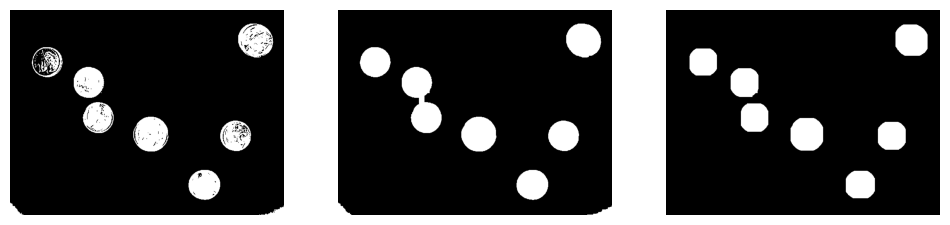

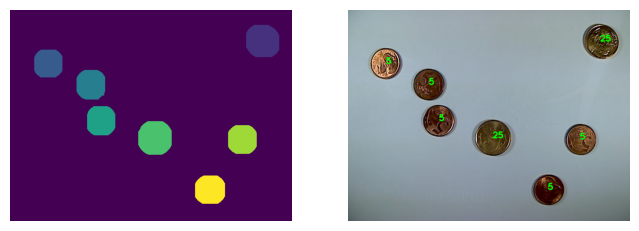

Imagem 75.jpg
Número de moedas 7
[np.int64(4805), np.int64(3638), np.int64(3867), np.int64(3786), np.int64(5016), np.int64(3767), np.int64(3861)]
Valor total: 75



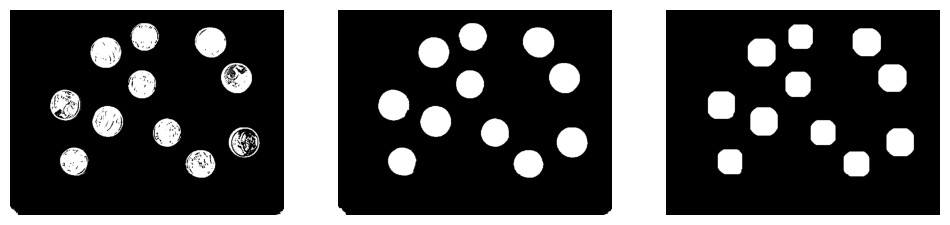

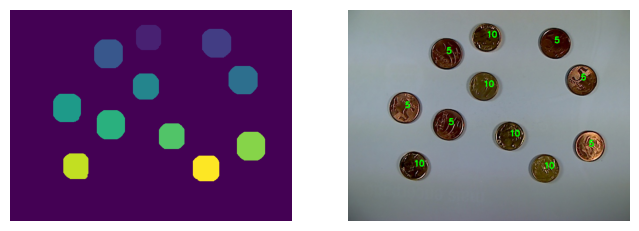

Imagem 80.jpg
Número de moedas 11
[np.int64(2978), np.int64(3793), np.int64(3775), np.int64(3736), np.int64(3132), np.int64(3678), np.int64(3778), np.int64(3064), np.int64(3728), np.int64(3049), np.int64(3183)]
Valor total: 80



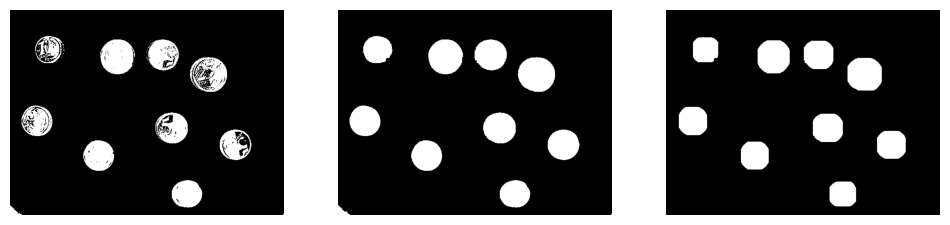

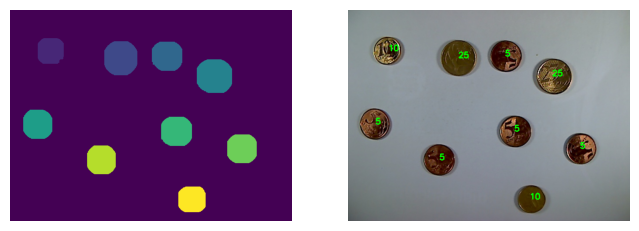

Imagem 95.jpg
Número de moedas 9
[np.int64(3114), np.int64(4997), np.int64(4017), np.int64(5335), np.int64(3845), np.int64(4113), np.int64(3897), np.int64(3766), np.int64(3285)]
Valor total: 95



In [54]:
for i, file in enumerate(filenames):
  img = mpimg.imread(file).astype('uint8')
  img_gray = np.uint8(0.3*img[:,:,0]+0.59*img[:,:,1]+0.11*img[:,:,2])

  seg_img = seg_and_postprocessing(img_gray, 15, 31)
  output = cv2.connectedComponentsWithStats(seg_img, 4)

  plt.figure(figsize=(8,4))
  plt.subplot(1,2,1)
  plt.imshow(output[1])
  plt.axis('off')

  list_npixels = calc_npixels_label(output[1], output[0])

  soma = 0
  for n, p in enumerate(list_npixels):
    x = int(output[3][n+1][0])
    y = int(output[3][n+1][1])

    if p < 3500:
      soma += 10
      cv2.putText(img, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    elif p > 4600:
      soma += 25
      cv2.putText(img, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    else:
      soma += 5
      cv2.putText(img, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

  plt.subplot(1,2,2)
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  print('Imagem', file)
  print('Número de moedas', len(list_npixels))
  print(list_npixels)
  print('Valor total:', soma)
  print()

### Exercício 3.1

Utilizando como base os códigos apresentados anteriormente, crie um novo Notebook que seja uma demonstração (demo) de como obter o valor total de um conjunto de moedas em uma imagem. O Notebook deve conter uma breve descrição do problema e deve explicar passo a passo as etapas e códigos utilizados para chegar ao resultado final. Tente descrever e exemplificar cada etapa, indicando qual o seu objetivo, explicando os processamentos aplicados, as funções utilizadas e os parâmetros escolhidos. Ao final do Notebook, apresente links para referências úteis no aprofundamento dos tópicos abordados. Você também pode linkar referências interessantes ao longo do Notebook, à medida que apresenta as etapas e os conceitos relacionados.

Não se esqueça de enviar o Notebook da demo juntamente com a entrega deste Notebook!